In [16]:
from datetime import date
import pandas as pd
import os
import glob
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
import umap

In [17]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [18]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"

annot_path = parent_directory  + "annotations/"

output_path = parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

# UMAP 

Settings:

n_neighbors = 30

min_dist = 0.1

In [19]:
def draw_umap(data,
              features,
              metadata,
              cell_type, 
              n_neighbors=15, 
              min_dist=0.1, 
              n_components=2, 
              metric='euclidean',
              title='',
              filename = ''):
    
    # function is a UMAP
    axis_1 = "UMAP_Axis_1"
    axis_2 = "UMAP_Axis_2"
    
    # plot params
    marker_color = ["lightgray", "purple"]
    marker_edgecolor = "none"
    marker_size = 15
    marker_alpha = 0.6
    
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    
    u = fit.fit_transform(features);

    u_dataframe = pd.DataFrame(data = u,
                               columns = [axis_1, 
                                          axis_2])

    # Get EOS annotation back
    u_dataframe_annot = pd.merge(data.loc[:, metadata], 
                                  u_dataframe, 
                                  left_index = True, 
                                  right_index = True)

    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))
    fig.suptitle(title, fontsize=18)
    
    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_' + cell_type + '_inactive',
        palette = ["lightgray", "navy"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_' + cell_type + '_Toxic',
        palette = ["lightgray", "purple"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_tubulin',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 2]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_DMSO',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Nocodazole',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Tetrandrine',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 2]
    )
    
    plt.savefig(filename)  

# Load and process annotations

In [20]:
annotation_compounds = pd.read_csv(annot_path + "pd_export_04_2022_2464_compounds_standardized.csv")
annotation_compounds.columns = annotation_compounds.columns.str.replace(' ', '_')
annotation_compounds = annotation_compounds.add_prefix('Metadata_')

In [21]:
annotation_targets = pd.read_csv(annot_path + 'pd_export_04_2022_2464_targets_standardized.csv')
annotation_targets.columns = annotation_targets.columns.str.replace(' ', '_')
annotation_targets = annotation_targets.add_prefix('Metadata_')
annotation_targets.shape

(29915, 31)

In [22]:
id_file = pd.read_csv(annot_path + "2024-08-02_EOS_pdid.csv")
id_file.shape

(2464, 2)

In [23]:
annotation_tubulin = pd.read_csv(annot_path + "2024-08-02_Tubulin.csv")
annotation_tubulin.shape

(2464, 2)

In [24]:
# get EUOS number 
annotation_compounds = pd.merge(annotation_compounds,
                     annotation_tubulin,
                     on = ["Metadata_pdid"],
                     how = "left",
                     indicator = False)

In [25]:
# get EUOS number 
annotation_compounds_2 = pd.merge(annotation_compounds,
                     id_file,
                     on = ["Metadata_pdid"],
                     how = "left",
                     indicator = False)

# U2OS

## Normalized data

In [26]:
# Load normalized data
file_U2OS_type = '/*[0-9]_' + 'FMP_U2OS_norm.csv'
files_U2OS = glob.glob(input_path + file_U2OS_type)

### gets latest file
max_file_U2OS = max(files_U2OS, key=os.path.getctime)

### load file
data_U2OS_Norm = pd.read_csv(max_file_U2OS)
data_U2OS_Norm.shape

(10629, 2984)

In [27]:
# U2OS feature reduction
print("Feature reduction with correlation threshold 0.9 and Outlier threshold 100")
U2OS_Reduced_Carsten_100_Mod = UTIL.feature_reduction(data_U2OS_Norm, 
                                         variance_freq_cut=0.1, 
                                         variance_unique_cut=0.1, 
                                         outlier_cutoff=100, 
                                         corr_threshold = 0.9, 
                                         print_stats = True)

Feature reduction with correlation threshold 0.9 and Outlier threshold 100
| Category           |   Original Features |   Variance Threshold |   % Variance |   Outlier Threshold |   % Outlier |   Correlation Threshold |   % Correlation |
|:-------------------|--------------------:|---------------------:|-------------:|--------------------:|------------:|------------------------:|----------------:|
| Total Features     |                2977 |                 2803 |         94.2 |                2071 |        69.6 |                     738 |            24.8 |
| Intensity          |                 180 |                  180 |        100   |                 125 |        69.4 |                      44 |            24.4 |
| Correlation        |                 180 |                  122 |         67.8 |                  99 |        55   |                      68 |            37.8 |
| AreaShape          |                 162 |                  155 |         95.7 |                 149 |      

## Remove non reproducible compounds

In [28]:
# data_U2OS_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm.csv")
file_U2OS_nonreplicating_type = '/*[0-9]_' + 'FMP_U2OS_non-replicating.csv'
files_U2OS_nonreplicating = glob.glob(input_path + file_U2OS_nonreplicating_type)

### gets latest file
max_files_U2OS_nonreplicating = max(files_U2OS_nonreplicating, key=os.path.getctime)

### load file
data_U2OS_nonreplicating = pd.read_csv(max_files_U2OS_nonreplicating)
data_U2OS_nonreplicating.shape

(261, 1)

In [29]:
FMP_U2OS_Data_replicating = U2OS_Reduced_Carsten_100_Mod.loc[~U2OS_Reduced_Carsten_100_Mod["Metadata_EOS"].isin(data_U2OS_nonreplicating["Metadata_EOS"])].copy()
FMP_U2OS_Data_replicating.shape

(9586, 745)

## Get toxic compounds

In [30]:
# data_U2OS_Median = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm_reduced_filtered_median.csv")
file_U2OS_tox_type = '/*[0-9]_' + 'FMP_U2OS_toxic_all.csv'
files_U2OS_tox = glob.glob(input_path + file_U2OS_tox_type)

### gets latest file
max_file_U2OS_tox = max(files_U2OS_tox, key=os.path.getctime)

### load file
data_U2OS_tox = pd.read_csv(max_file_U2OS_tox)
data_U2OS_tox.shape

(177, 1)

In [31]:
data_U2OS_tox_annot = pd.merge(data_U2OS_tox,
                               id_file,
                               on = ["Metadata_EOS"],
                               how = "left",
                               indicator = True)

In [32]:
annotation_compounds_2['Metadata_U2OS_Toxic'] = annotation_compounds_2['Metadata_pdid'].isin(data_U2OS_tox_annot['Metadata_pdid'])

## Get low active compounds

In [33]:
file_U2OS_inactive_type = '/*[0-9]_' + 'FMP_U2OS_low-active.csv'
files_U2OS_inactive = glob.glob(input_path + file_U2OS_inactive_type)

### gets latest file
max_file_U2OS_inactive = max(files_U2OS_inactive, key=os.path.getctime)

### load file
data_U2OS_inactive = pd.read_csv(max_file_U2OS_inactive)
data_U2OS_inactive.shape

(690, 1)

In [34]:
data_U2OS_inactive_annot = pd.merge(data_U2OS_inactive,
                               id_file,
                               on = ["Metadata_EOS"],
                               how = "left",
                               indicator = True)

In [35]:
annotation_compounds_2['Metadata_U2OS_inactive'] = annotation_compounds_2['Metadata_pdid'].isin(data_U2OS_inactive_annot['Metadata_pdid'])

## Process for visualization

In [36]:
## gets feature vector
Features_U2OS_Norm_Reduced = UTIL.get_feature_vector(FMP_U2OS_Data_replicating)

Features_U2OS_Norm_Reduced_Median = pycytominer.consensus(
        profiles = FMP_U2OS_Data_replicating, # A file or pandas DataFrame of profile data
        replicate_columns = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"], # Metadata columns indicating which replicates to collapse, defaults to [“Metadata_Plate”, “Metadata_Well”]
        operation = "median", # (str) – The method used to form consensus profiles, defaults to “median”
        features = Features_U2OS_Norm_Reduced, # (str, list) – The features to collapse, defaults to “infer”
)

In [37]:
U2OS_Norm_Reduced_Median_annot = pd.merge(Features_U2OS_Norm_Reduced_Median,
                                              id_file,
                                              how = 'left',
                                              on=['Metadata_EOS'])

In [38]:
U2OS_Norm_Reduced_Median_annot2 = pd.merge(U2OS_Norm_Reduced_Median_annot,
                                              annotation_compounds_2,
                                              how = 'left',
                                              on=['Metadata_EOS'])

In [39]:
U2OS_Norm_Reduced_Median_annot2['Metadata_Nocodazole'] = U2OS_Norm_Reduced_Median_annot2['Metadata_EOS'].str.contains('Nocodazole', case=False, na=False)
U2OS_Norm_Reduced_Median_annot2['Metadata_Tetrandrine'] = U2OS_Norm_Reduced_Median_annot2['Metadata_EOS'].str.contains('Tetrandrine', case=False, na=False)
U2OS_Norm_Reduced_Median_annot2['Metadata_DMSO'] = U2OS_Norm_Reduced_Median_annot2['Metadata_EOS'].str.contains('DMSO', case=False, na=False)

In [44]:
# Data without metadata columns
FMP_U2OS_Data = U2OS_Norm_Reduced_Median_annot2.reset_index(drop = True)
FMP_U2OS_Features = UTIL.get_feature_vector(FMP_U2OS_Data)
FMP_U2OS_Meta_Features = list(set(FMP_U2OS_Data.columns) - set(FMP_U2OS_Features ))
    
FMP_U2OS_x = FMP_U2OS_Data.loc[:, FMP_U2OS_Features]

In [45]:
FMP_U2OS_Data['Metadata_tubulin'].fillna(False,inplace=True)
FMP_U2OS_Data['Metadata_U2OS_Toxic'].fillna(False,inplace=True)
FMP_U2OS_Data['Metadata_U2OS_inactive'].fillna(False,inplace=True)

## Visualization with UMAP

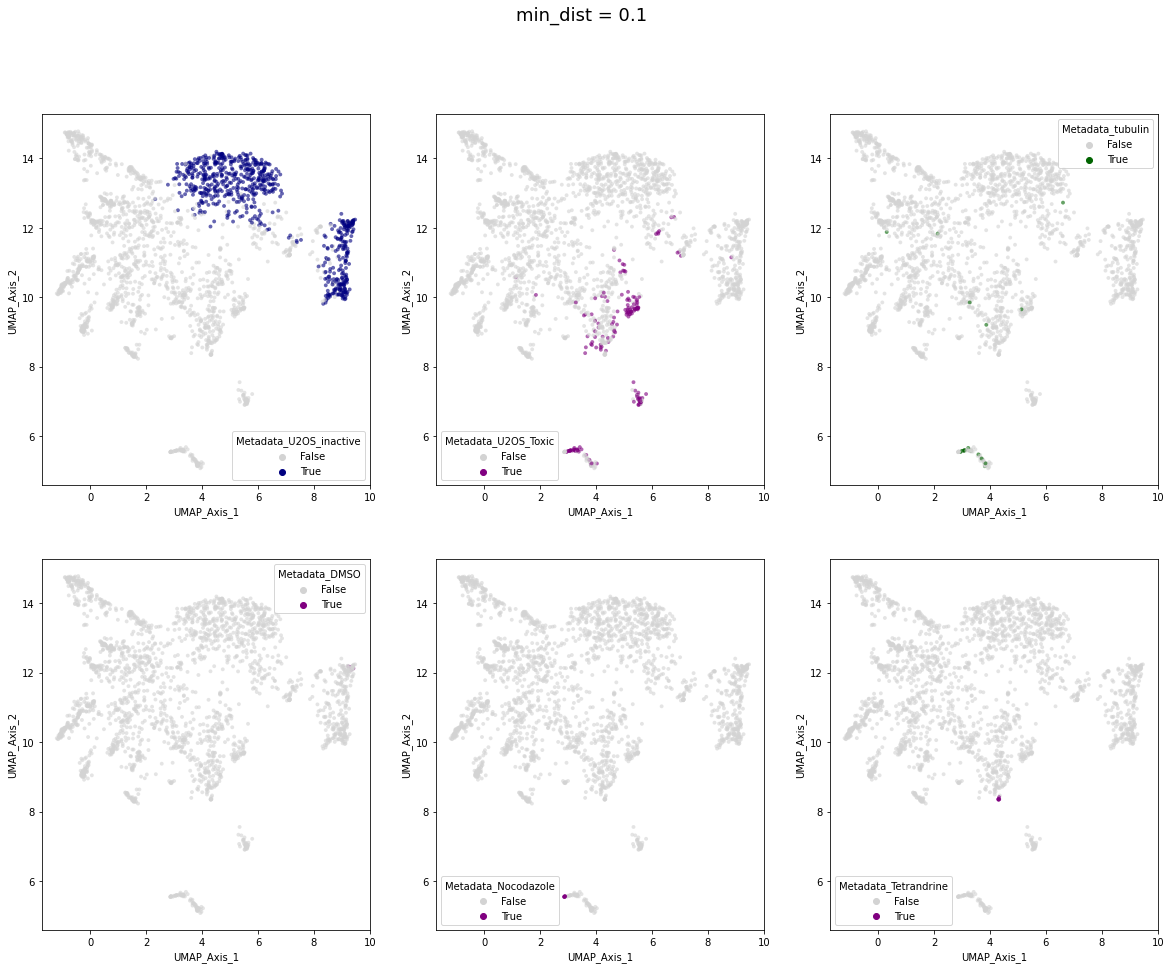

In [46]:
filename_U2OS_UMAP = figure_path + str(date.today()) + "_FMP_U2OS_UMAP_2D_VizOnly.pdf"

draw_umap(data = FMP_U2OS_Data,
          features = FMP_U2OS_x,
          metadata = FMP_U2OS_Meta_Features,
          cell_type='U2OS',
          n_neighbors=30,
          min_dist=0.1,
          title='min_dist = {}'.format(0.1),
          filename = filename_U2OS_UMAP)

# UMAP Cell count senescence


In [47]:
U2OS_Norm_Reduced_Median_annot2.columns.tolist()

['Metadata_EOS',
 'Metadata_Plate',
 'Metadata_Concentration',
 'Metadata_Partner',
 'Nuc_AreaShape_BoundingBoxArea',
 'Nuc_AreaShape_BoundingBoxMinimum_X',
 'Nuc_AreaShape_Compactness',
 'Nuc_AreaShape_Extent',
 'Nuc_AreaShape_FormFactor',
 'Nuc_AreaShape_MinFeretDiameter',
 'Nuc_AreaShape_Orientation',
 'Nuc_AreaShape_Zernike_0_0',
 'Nuc_AreaShape_Zernike_1_1',
 'Nuc_AreaShape_Zernike_3_1',
 'Nuc_AreaShape_Zernike_4_0',
 'Nuc_AreaShape_Zernike_4_2',
 'Nuc_AreaShape_Zernike_4_4',
 'Nuc_AreaShape_Zernike_5_1',
 'Nuc_AreaShape_Zernike_5_3',
 'Nuc_AreaShape_Zernike_5_5',
 'Nuc_AreaShape_Zernike_6_0',
 'Nuc_AreaShape_Zernike_6_2',
 'Nuc_AreaShape_Zernike_6_4',
 'Nuc_AreaShape_Zernike_6_6',
 'Nuc_AreaShape_Zernike_7_1',
 'Nuc_AreaShape_Zernike_7_3',
 'Nuc_AreaShape_Zernike_7_5',
 'Nuc_AreaShape_Zernike_7_7',
 'Nuc_AreaShape_Zernike_8_0',
 'Nuc_AreaShape_Zernike_8_2',
 'Nuc_AreaShape_Zernike_8_4',
 'Nuc_AreaShape_Zernike_8_6',
 'Nuc_AreaShape_Zernike_8_8',
 'Nuc_AreaShape_Zernike_9_1',
 'Nu

In [48]:
# Visualization on UMAP space on how different parameters are related. 

# Nuc_Intensity_MeanIntensity_DNA
# Cells_AreaShape_Area
# Metadata_Object_Count
data_U2OS_Norm.columns.tolist()

['Metadata_EOS',
 'Metadata_Object_Count',
 'Metadata_Plate',
 'Metadata_Well',
 'Metadata_Partner',
 'Metadata_Batch',
 'Metadata_Concentration',
 'Nuc_AreaShape_Area',
 'Nuc_AreaShape_BoundingBoxArea',
 'Nuc_AreaShape_BoundingBoxMaximum_X',
 'Nuc_AreaShape_BoundingBoxMaximum_Y',
 'Nuc_AreaShape_BoundingBoxMinimum_X',
 'Nuc_AreaShape_BoundingBoxMinimum_Y',
 'Nuc_AreaShape_Center_X',
 'Nuc_AreaShape_Center_Y',
 'Nuc_AreaShape_Compactness',
 'Nuc_AreaShape_Eccentricity',
 'Nuc_AreaShape_EquivalentDiameter',
 'Nuc_AreaShape_EulerNumber',
 'Nuc_AreaShape_Extent',
 'Nuc_AreaShape_FormFactor',
 'Nuc_AreaShape_MajorAxisLength',
 'Nuc_AreaShape_MaxFeretDiameter',
 'Nuc_AreaShape_MaximumRadius',
 'Nuc_AreaShape_MeanRadius',
 'Nuc_AreaShape_MedianRadius',
 'Nuc_AreaShape_MinFeretDiameter',
 'Nuc_AreaShape_MinorAxisLength',
 'Nuc_AreaShape_Orientation',
 'Nuc_AreaShape_Perimeter',
 'Nuc_AreaShape_Solidity',
 'Nuc_AreaShape_Zernike_0_0',
 'Nuc_AreaShape_Zernike_1_1',
 'Nuc_AreaShape_Zernike_2_0',

In [49]:
## gets feature vector
Features_U2OS_Norm = UTIL.get_feature_vector(data_U2OS_Norm)
Features_U2OS_Norm.append("Metadata_Object_Count") # include object count to compute median

In [50]:
# compute median of U2OS
Features_U2OS_Norm_Median = pycytominer.consensus(
        profiles = data_U2OS_Norm, # A file or pandas DataFrame of profile data
        replicate_columns = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"], # Metadata columns indicating which replicates to collapse, defaults to [“Metadata_Plate”, “Metadata_Well”]
        operation = "median", # (str) – The method used to form consensus profiles, defaults to “median”
        features = Features_U2OS_Norm, # (str, list) – The features to collapse, defaults to “infer”
)

In [51]:
Features_U2OS_Norm_Median.head()

,Metadata_EOS,Metadata_Plate,Metadata_Concentration,Metadata_Partner,Nuc_AreaShape_Area,Nuc_AreaShape_BoundingBoxArea,Nuc_AreaShape_BoundingBoxMaximum_X,Nuc_AreaShape_BoundingBoxMaximum_Y,Nuc_AreaShape_BoundingBoxMinimum_X,Nuc_AreaShape_BoundingBoxMinimum_Y,...,Cyto_Texture_Variance_Mito_10_03_256,Cyto_Texture_Variance_Mito_3_00_256,Cyto_Texture_Variance_Mito_3_01_256,Cyto_Texture_Variance_Mito_3_02_256,Cyto_Texture_Variance_Mito_3_03_256,Cyto_Texture_Variance_Mito_5_00_256,Cyto_Texture_Variance_Mito_5_01_256,Cyto_Texture_Variance_Mito_5_02_256,Cyto_Texture_Variance_Mito_5_03_256,Metadata_Object_Count
0,DMSO,B1001,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,5.030698e-17,0.000000e+00,0.0,-9.887924e-17,0.000000e+00,5.030698e-17,0.000000e+00,-4.857226e-17,0.000000e+00,662.0
1,DMSO,B1002,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,1.500536e-16,-1.006140e-16,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.006140e-16,681.5
2,DMSO,B1003,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,1.006140e-16,0.0,0.000000e+00,-1.500536e-16,0.000000e+00,1.491862e-16,0.000000e+00,0.000000e+00,648.5
3,DMSO,B1004,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,9.974660e-17,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,655.0
4,DMSO,B1005,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,651.5


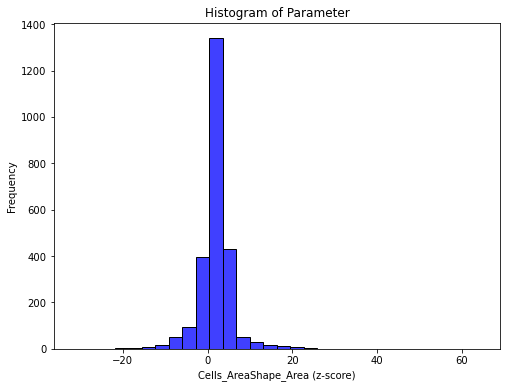

In [52]:
plt.figure(figsize=(8, 6))
sns.histplot(Features_U2OS_Norm_Median["Cells_AreaShape_Area"], bins=30, kde=False, color='blue')
plt.title("Histogram of Parameter")
plt.xlabel("Cells_AreaShape_Area (z-score)")
plt.ylabel("Frequency")
plt.show()

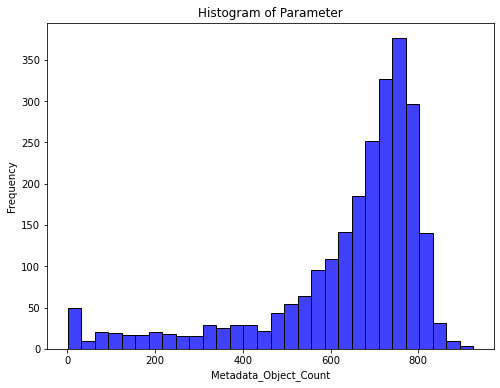

In [53]:
# 1. Histogram
plt.figure(figsize=(8, 6))
sns.histplot(Features_U2OS_Norm_Median["Metadata_Object_Count"], bins=30, kde=False, color='blue')
plt.title("Histogram of Parameter")
plt.xlabel("Metadata_Object_Count")
plt.ylabel("Frequency")
plt.show()

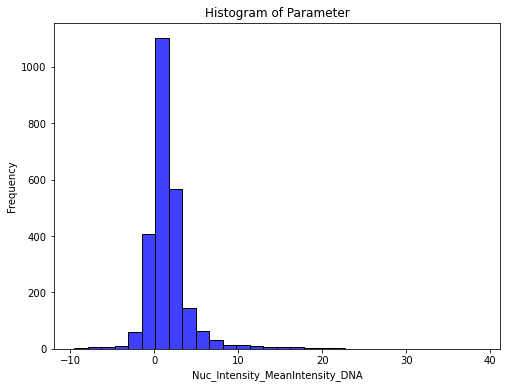

In [54]:
# 1. Histogram
plt.figure(figsize=(8, 6))
sns.histplot(Features_U2OS_Norm_Median["Nuc_Intensity_MeanIntensity_DNA"], bins=30, kde=False, color='blue')
plt.title("Histogram of Parameter")
plt.xlabel("Nuc_Intensity_MeanIntensity_DNA")
plt.ylabel("Frequency")
plt.show()

In [55]:
# Threshold for senescence related features
## Intensity nuc <2 z-score
## Cell area >2 z-score
Features_U2OS_Norm_Median["Nuc_Intensity_low"] = Features_U2OS_Norm_Median["Nuc_Intensity_MeanIntensity_DNA"] < -5
Features_U2OS_Norm_Median["Cells_AreaShape_high"] = Features_U2OS_Norm_Median["Cells_AreaShape_Area"] > 5

In [56]:
data_U2OS_senescence = Features_U2OS_Norm_Median[['Metadata_EOS',
                                        'Metadata_Object_Count',
                                        'Metadata_Plate',
                                        'Metadata_Partner',
                                        'Metadata_Concentration',
                                        'Nuc_Intensity_low', 
                                        'Cells_AreaShape_high']].copy()

In [57]:
data_U2OS_senescence['Sensescence_params'] = data_U2OS_senescence['Nuc_Intensity_low'] & data_U2OS_senescence['Cells_AreaShape_high']

In [58]:
# cell number bin
# Define the fixed bin edges with a width of 200
# bins = [0, 200, 400, 600, 800, 1000, 1200, 1400]
bins = [0, 300, 600, 900, 1300]

# Define the labels for each bin (1-7)
# bin_labels = [1, 2, 3, 4, 5, 6, 7]
bin_labels = [1, 2, 3, 4]

# Create the new column 'bin' based on the defined bins and labels
data_U2OS_senescence['cell_bin'] = pd.cut(data_U2OS_senescence["Metadata_Object_Count"], bins=bins, labels=bin_labels, right=True)

In [59]:
FMP_U2OS_merged = pd.merge(FMP_U2OS_Data, data_U2OS_senescence, on=['Metadata_EOS',
                                                                'Metadata_Plate',
                                                                'Metadata_Partner',
                                                                'Metadata_Concentration'])

In [60]:
FMP_U2OS_merged.head()

,Metadata_EOS,Metadata_Plate,Metadata_Concentration,Metadata_Partner,Nuc_AreaShape_BoundingBoxArea,Nuc_AreaShape_BoundingBoxMinimum_X,Nuc_AreaShape_Compactness,Nuc_AreaShape_Extent,Nuc_AreaShape_FormFactor,Nuc_AreaShape_MinFeretDiameter,...,Metadata_U2OS_Toxic,Metadata_U2OS_inactive,Metadata_Nocodazole,Metadata_Tetrandrine,Metadata_DMSO,Metadata_Object_Count,Nuc_Intensity_low,Cells_AreaShape_high,Sensescence_params,cell_bin
0,DMSO,B1001,0,Bioactives,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,...,False,False,False,False,True,662.0,False,False,False,3
1,DMSO,B1002,0,Bioactives,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,...,False,False,False,False,True,681.5,False,False,False,3
2,DMSO,B1003,0,Bioactives,0.0,0.0,-1.470005e-14,0.0,0.0,0.000000e+00,...,False,False,False,False,True,648.5,False,False,False,3
3,DMSO,B1004,0,Bioactives,0.0,0.0,1.919992e-14,0.0,0.0,-6.200119e-15,...,False,False,False,False,True,655.0,False,False,False,3
4,DMSO,B1005,0,Bioactives,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,...,False,False,False,False,True,651.5,False,False,False,3


# Senescence UMAP

In [61]:
# SN-38, PALBOCICLIB, CAMPTOTHECIN, Ciclopirox ethanolamine, RGB-286638, FLUDARABINE
senescence_compounds = ["SN-38", "PALBOCICLIB", "CAMPTOTHECIN", "CICLOPIROX", "RGB-286638", "FLUDARABINE"]

In [62]:
senescence_compounds_EOS = FMP_U2OS_merged[FMP_U2OS_merged["Metadata_name"].isin(senescence_compounds)]["Metadata_EOS"].unique()

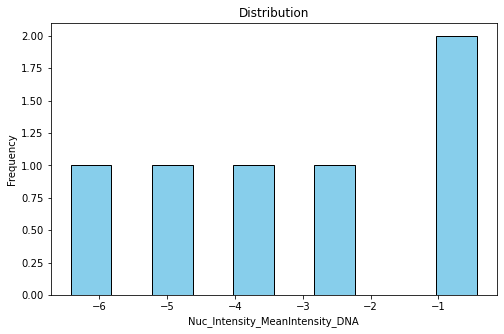

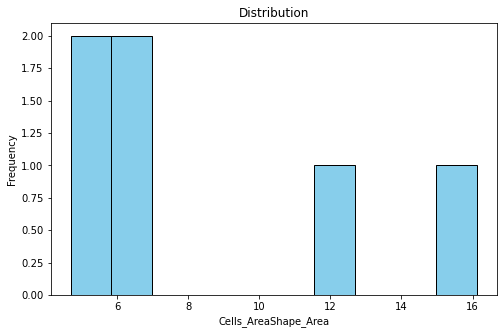

In [63]:
#TODO: identify EOS number of senescence compounds
senescence_features_median = Features_U2OS_Norm_Median[Features_U2OS_Norm_Median["Metadata_EOS"].isin(senescence_compounds_EOS)]

plt.figure(figsize=(8, 5))
plt.hist(senescence_features_median['Nuc_Intensity_MeanIntensity_DNA'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution')
plt.xlabel('Nuc_Intensity_MeanIntensity_DNA')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(senescence_features_median['Cells_AreaShape_Area'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution')
plt.xlabel('Cells_AreaShape_Area')
plt.ylabel('Frequency')
plt.show()

In [64]:
# colors = sns.color_palette("Set2", 7)
colors = sns.color_palette("Set2", 4)

In [65]:
def draw_umap(data,
              features,
              metadata,
              cell_type, 
              n_neighbors=15, 
              min_dist=0.1, 
              n_components=2, 
              metric='euclidean',
              title='',
              filename = ''):
    
    # function is a UMAP
    axis_1 = "UMAP_Axis_1"
    axis_2 = "UMAP_Axis_2"
    
    # plot params
    marker_color = ["lightgray", "purple"]
    marker_edgecolor = "none"
    marker_size = 15
    marker_alpha = 0.6
    
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    
    u = fit.fit_transform(features)

    u_dataframe = pd.DataFrame(data = u,
                               columns = [axis_1, 
                                          axis_2])

    # Get EOS annotation back
    u_dataframe_annot = pd.merge(data.loc[:, metadata], 
                                  u_dataframe, 
                                  left_index = True, 
                                  right_index = True)
    
    ### 
    filename_umap = output_path + str(date.today()) + "_FMP_U2OS_UMAP.csv"
    u_dataframe_annot.to_csv(filename_umap, index = False)
    
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 7))
    fig.suptitle(title, fontsize=18)

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        edgecolor = marker_edgecolor,
        hue = 'cell_bin',
        palette = colors,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Sensescence_params',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        zorder=1,
        ax=axs[1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        edgecolor = marker_edgecolor,
        color = ["lightgray"],
        s = marker_size,
        alpha = marker_alpha,
        zorder=1,
        ax=axs[2]
    )


        # Add labels for specific points based on matching IDs
    for i, row in u_dataframe_annot.iterrows():
        if row["Metadata_name"] in senescence_compounds:  # Check if the ID matches the target list

            plt.scatter(row["UMAP_Axis_1"], 
                        row["UMAP_Axis_2"], 
                        color = 'red',
                        s=marker_size, 
                        alpha = 1,
                        zorder=3)

            plt.annotate(
                row["Metadata_name"],  # The label text
                (row["UMAP_Axis_1"], row["UMAP_Axis_2"]),  # The (x, y) coordinates
                textcoords="offset points",  # Positioning the label
                xytext=(5, 5),  # Offset from the point
                ha="center",  # Horizontal alignment
                fontsize=6,  # Font size
                color="red"  # Text color
             )
       
    plt.savefig(filename)

In [66]:
# Data without metadata columns
FMP_U2OS_merged_reset = FMP_U2OS_merged.reset_index(drop = True)
FMP_U2OS_merged_reset_Features = UTIL.get_feature_vector(FMP_U2OS_merged_reset)
FMP_U2OS_merged_reset_Meta_Features = list(set(FMP_U2OS_merged_reset.columns) - set(FMP_U2OS_merged_reset_Features))
    
FMP_U2OS_merged_reset_x = FMP_U2OS_merged_reset.loc[:,FMP_U2OS_merged_reset_Features]

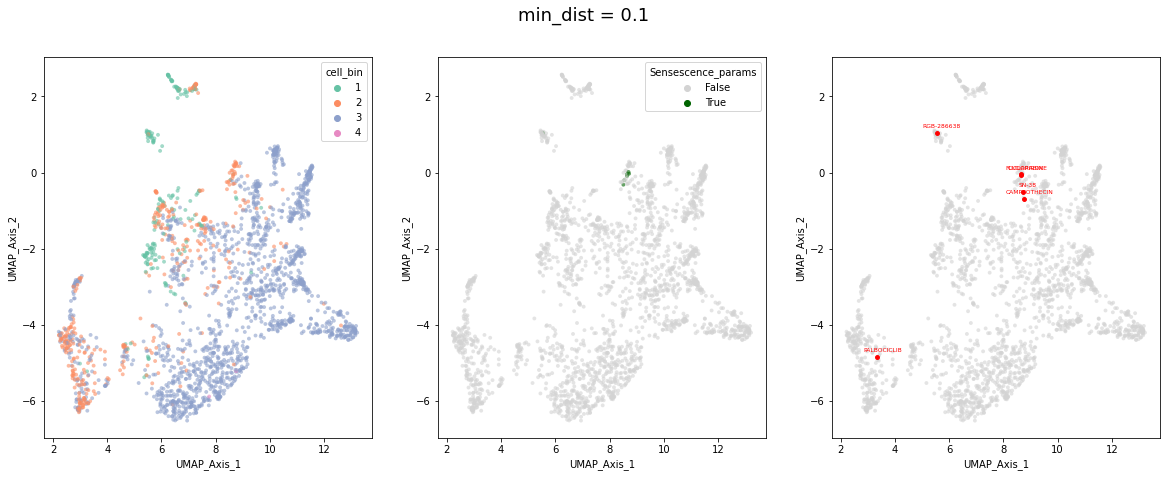

In [67]:
filename_U2OS_UMAP = figure_path + str(date.today()) + "_FMP_U2OS_UMAP_2D_Senescence.pdf"

draw_umap(data = FMP_U2OS_merged,
          features = FMP_U2OS_merged_reset_x,
          metadata = FMP_U2OS_merged_reset_Meta_Features,
          cell_type='U2OS',
          n_neighbors=30,
          min_dist=0.1,
          title='min_dist = {}'.format(0.1),
          filename = filename_U2OS_UMAP)